In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('housing.csv')

In [3]:
# 1. Map Yes/No to 1/0
binary_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_columns:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# 2. One-Hot Encode 'furnishingstatus'
# This drops the first option to avoid the "dummy variable trap" (collinearity)
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True, dtype=int)

In [4]:
# Calculate the correlation of all features against 'price'
# We use numeric_only=True to ignore any leftover text columns
correlations = df.corr(numeric_only=True)['price'].sort_values(ascending=False)

print("Correlation with Price:")
print(correlations)

Correlation with Price:
price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


In [11]:
selected_features = ['area' , 'bathrooms' , 'airconditioning' , 'stories' , 'parking' , 'bedrooms']

X_raw = df[selected_features].values

y_train = df['price'].values / 100000

print(f"Final X shape: {X_raw.shape}")
print(f"We are training on {X_raw.shape[0]} houses using {X_raw.shape[1]} features.")

Final X shape: (545, 6)
We are training on 545 houses using 6 features.


In [14]:
def compute_z_score(X):
    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)

    X_Scaled = (X - mu) / sigma

    return X_Scaled, mu, sigma

X_train, mu_X, sigma_X = compute_z_score(X_raw)

print(f"Original First House : {X_raw[0]}")
print(f"Scaled first house : {X_train[0]}")

Original First House : [7420    2    1    3    2    4]
Scaled first house : [1.04672629 1.42181174 1.4726183  1.37821692 1.51769249 1.40341936]


In [ ]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    
    f_wb = np.dot(X , w) + b
    total_cost = np.sum((f_wb - y)**2) / (2 * m)
    
    return total_cost

In [9]:
def compute_gradient(X, y, w, b):

    m = X.shape[0]

    f_wb = np.dot(X , w) + b
    err = f_wb - y

    dj_dw = np.dot(X.T , err) / m
    dj_db = np.sum(err) / m
    
    return dj_dw, dj_db


In [10]:
def gradient_descent(X, y, w, b, Alpha, num_iters):
    
    J_history = []


    for i in range(num_iters):
        dj_dw , dj_db = compute_gradient(X, y, w, b)

        w = w - Alpha * dj_dw
        b = b - Alpha * dj_db

        cost = compute_cost(X, y, w, b)

        J_history.append(cost)

        if i % 1000 == 0:
            print(f"Iterations : {i:4d} | Cost : {cost:.4f}")
    
    
    return w, b, J_history

In [12]:
# Initialize starting w and b
initial_w = np.zeros(X_train.shape[1])
initial_b = 0.0

# Set hyperparameters
iterations = 5000
alpha = 0.01

# RUN IT!
print("Starting Gradient Descent...\n")
final_w, final_b, J_hist = gradient_descent(X_train, y_train, initial_w, initial_b, alpha, iterations)

print("\n--- Training Complete ---")
print(f"Final Weights: {final_w}")
print(f"Final Bias: {final_b}")

Starting Gradient Descent...

Iterations :    0 | Cost : 1283.8693
Iterations : 1000 | Cost : 68.6640
Iterations : 2000 | Cost : 68.6639
Iterations : 3000 | Cost : 68.6639
Iterations : 4000 | Cost : 68.6639

--- Training Complete ---
Final Weights: [6.48981004 5.44406364 4.27029602 3.64530722 2.90668388 1.24754562]
Final Bias: 47.667292477063874


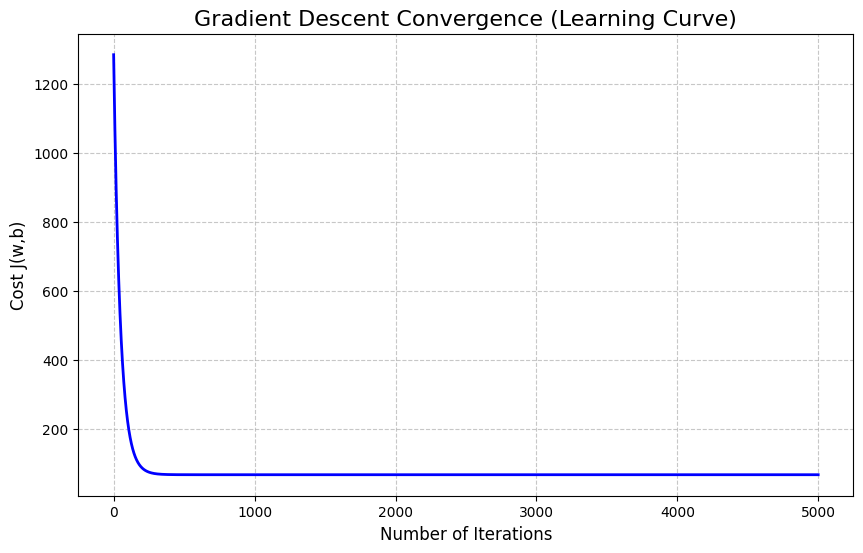

In [13]:
import matplotlib.pyplot as plt

# Create a figure
plt.figure(figsize=(10, 6))

# Plot the cost history list
# By default, plt.plot(list) uses the list index (0, 1, 2...) for the X-axis!
plt.plot(J_hist, color='blue', linewidth=2)

# Add titles and labels
plt.title("Gradient Descent Convergence (Learning Curve)", fontsize=16)
plt.xlabel("Number of Iterations", fontsize=12)
plt.ylabel("Cost J(w,b)", fontsize=12)

# Add a grid to make it easier to read
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.show()

In [18]:
# 1. Define your custom house
# The features MUST be in the exact same order you trained them:
# ['area', 'bathrooms', 'airconditioning', 'stories', 'parking', 'bedrooms']

# Let's say: 6000 sqft, 3 baths, Has AC (1), 2 stories, 2 parking spots, 4 bedrooms
new_house = np.array([6000, 3, 1, 1, 0, 2])

# 2. Scale the new house using the TRAINING data's mean and standard deviation
new_house_scaled = (new_house - mu_X) / sigma_X

# 3. Run the prediction! (Dot product of scaled features and your final weights + bias)
predicted_price_scaled = np.dot(new_house_scaled, final_w) + final_b

# 4. Convert it back to a normal currency number
actual_price = predicted_price_scaled * 100000

print("--- AI Real Estate Agent ---")
print(f"Features: {new_house}")
print(f"Predicted Price: ${actual_price:,.2f}")

--- AI Real Estate Agent ---
Features: [6000    3    1    1    0    2]
Predicted Price: $6,772,061.24


In [20]:
import pickle

# Bundle everything the model needs to make predictions into a dictionary
model_data = {
    'weights': final_w,
    'bias': final_b,
    'mu': mu_X,
    'sigma': sigma_X
}

# Save it to a file called 'house_model.pkl'
with open('house_model.pkl', 'wb') as file:
    pickle.dump(model_data, file)

print("Model successfully exported!")

Model successfully exported!
